# GEARS — Notebook 5: Generic (non-French) Dataset Example

**Objective:** Demonstrate the full GEARS pipeline — data loading, exploratory analysis,
session-count forecasting, `GEARSModel` session simulation (GMM backend), distribution
comparison, and V1G smart charging — on a **non-French, non-`sample_df`** dataset, using
the generalized `load_sessions()` column-alias resolution added for the 11-dataset EVSE
benchmark (see `gears/data/schemas.py`).

**Dataset choice:** of the 11 EVSE benchmark CSVs, `sap.csv` is used here (26,430 sessions,
2017-06 → 2021-01, single site, no `department`/`location_type` columns — a genuinely
generic single-site dataset). It was chosen over the originally-suggested `palo_alto.csv`
for notebook runtime: `palo_alto.csv` is actually the largest of the 11 (258k rows, ~9.4y
span) rather than the "light" example it was assumed to be — see the benchmark prompt's
ground-truth appendix (§1.7). Swap `DATA_PATH`/`EVAL_DATE` below to run this notebook on
any of the other 10 files instead.

This notebook mirrors `2_gmm_forecasting.ipynb`'s structure, imports, and plotting
conventions (Okabe-Ito-adjacent palette, general layout) for visual consistency — but
**skips everything VAE-related** (VAE is out of scope for this genericization pass) and
**skips the department-level split** (`SIM_DEPTS`/`SARIMA_DEPT`) since generic single-site
datasets have no department column: the whole dataset is one site.

**This is also the "bring your own data" walkthrough** referenced in
[`data/README.md`](../data/README.md#your-own-data-custom): `sap.csv` is staged at
`data/custom/sap.csv` below rather than `data/preprocessed_data/` to demonstrate the exact
path a first-time user follows — drop a correctly-shaped CSV under `data/custom/`, point
`load_sessions()` at it, done. Section 2 also runs a quick load-and-validate check on
`domestics.csv` (UK residential charging — a genuinely different usage profile from
`sap.csv`'s workplace+home fleet, see `data/README.md`) to show the same schema handles
both without any code changes, without paying for a second full pipeline run.

**Sections**
1. Configuration & data loading
2. Exploratory analysis
3. D-1 train/test split
4. Session-count forecasters (SARIMA, Persistence)
5. Forecast comparison & metrics
6. `GEARSModel` — simulate individual sessions (GMM)
7. Daily energy forecast
8. Real vs. simulated distributions
9. V1G smart charging — optimisation
10. Regret analysis
11. Load-shift visualisation

In [1]:
import warnings; warnings.filterwarnings("ignore")
import os; os.makedirs("outputs", exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

import gears
from gears import (
    GEARSModel, load_sessions,
    SessionForecaster, NHiTSForecaster, PersistenceForecaster,
    sessions_to_daily_counts,
)
from gears.smart_charging.optimizer import SmartChargingOptimizer
from gears.utils import make_price_signal, forecast_metrics, distribution_comparison
from gears import plotting

## 1. Configuration

In [2]:
# ── User-configurable constants ──────────────────────────────────────────────
DATA_PATH      = "../data/custom/sap.csv"  # any correctly-shaped CSV under data/custom/ works here
EVAL_DATE      = "2020-01-15"              # first day of evaluation window (D-day)
HORIZON        = 14                        # evaluation window in days
N_SCENARIOS    = 15                        # stochastic scenarios for fan charts
MAX_SAMPLES    = 500                       # max GMM training samples per context
RESOLUTION     = 30                        # price-signal resolution in minutes
RECENT_MONTHS  = 12                        # history window for SARIMA/GMM fitting

# This dataset has no ISO country code attached to it in the raw CSV, so rather
# than guess (and silently apply the wrong public-holiday calendar), holidays
# are disabled here. GEARSModel now accepts forecaster_use_holidays/
# forecaster_country pass-throughs (added in this genericization pass — see
# gears/pipeline.py) precisely so this is a config choice, not a hardcoded
# French assumption: if you know your site's country, set
# FORECASTER_COUNTRY = "US" (or your ISO code) and FORECASTER_USE_HOLIDAYS = True.
FORECASTER_USE_HOLIDAYS = False
FORECASTER_COUNTRY = "US"

# Note on EVAL_DATE: this dataset's session volume collapses sharply from
# March 2020 onward (workplace charging during COVID lockdowns/WFH — a real
# feature of the data, not a bug) and stays volatile through the file's end
# in Jan 2021. EVAL_DATE is set inside the earlier, stable pre-2020 period so
# this notebook demonstrates the pipeline under "normal" conditions; feel
# free to move it later to see how SARIMA behaves across that disruption.

TRAIN_END = pd.Timestamp(EVAL_DATE) - pd.Timedelta(days=1)
print(f"Training window : last {RECENT_MONTHS} months, up to {TRAIN_END.date()}")
print(f"Evaluation window: {EVAL_DATE} → "
      f"{(pd.Timestamp(EVAL_DATE)+pd.Timedelta(days=HORIZON-1)).date()}")

Training window : last 12 months, up to 2020-01-14
Evaluation window: 2020-01-15 → 2020-01-28


## 2. Data loading

No department pre-filtering here (unlike notebook 2) — this is a single-site dataset,
so `load_sessions()` is called directly on the full CSV. A second, unrelated dataset
(`domestics.csv`) is loaded right after purely to confirm the same schema/loader handles
a differently-shaped file with no changes — see the intro above.


In [3]:
df = load_sessions(DATA_PATH, verbose=True)

print(f"\nDataset: {len(df):,} sessions")
print(f"Date range        : {df['arrival_time'].min().date()} → {df['arrival_time'].max().date()}")
print(f"Columns           : {df.columns.tolist()}")

[GEARS] Loaded 26,430 sessions.
            count       mean        std       min        25%        50%        75%        max  missing_%
duration  26430.0   4.370236   3.406144  0.002778   2.013611   3.598194   5.722986  23.947778        0.0
energy    26430.0  23.388512  14.501248  0.001000  12.761250  20.953000  31.600750  99.262000        0.0

Dataset: 26,430 sessions
Date range        : 2017-06-01 → 2021-01-01
Columns           : ['arrival_time', 'end_time', 'Arrival', 'Charge.Duration', 'Idle.Duration', 'Park.Duration', 'energy', 'duration', 'hour', 'day_of_week', 'month', 'season', 'is_weekend', 'date']


In [4]:
# ── Portability check: a second, unrelated dataset through the same loader ──────────
# domestics.csv (UK residential charging, ~221k sessions) is a genuinely different usage
# profile from sap.csv (workplace+home fleet, single site) — different country, different
# charging context, different scale. Loading it here (without running the rest of the
# pipeline on it, to keep this notebook's runtime bounded) is the concrete demonstration
# that "works on any properly-shaped dataset" from data/README.md's "Your own data"
# section: no code changes, same load_sessions() call, same canonical schema out.
df_domestics = load_sessions("../data/custom/domestics.csv", verbose=False)
arr = df_domestics["arrival_time"]
print(f"domestics.csv: {len(df_domestics):,} sessions | columns: {df_domestics.columns.tolist()}")
print(f"Date range    : {arr.min().date()} -> {arr.max().date()}")
del df_domestics, arr  # only needed for this schema-portability check, not used downstream


domestics.csv: 220,870 sessions | columns: ['arrival_time', 'end_time', 'Arrival', 'Park.Duration', 'energy', 'duration', 'hour', 'day_of_week', 'month', 'season', 'is_weekend', 'date']
Date range    : 2017-01-02 -> 2017-12-29


## 3. Exploratory analysis

No `location_type`/`department` columns in this dataset — `plotting` functions accept a
`group_by` column and gracefully skip faceting if it isn't present, so `is_weekend` is
used as the facet here instead.

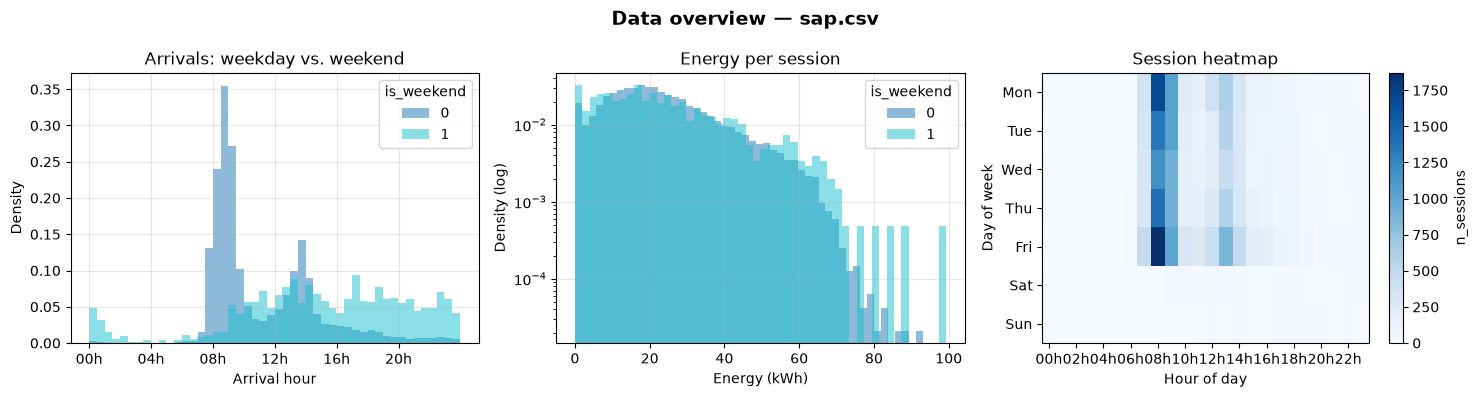

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
plotting.plot_arrival_distribution(df, group_by="is_weekend", ax=axes[0],
    title="Arrivals: weekday vs. weekend")
axes[0].set_xticks(range(0, 24, 4))
axes[0].set_xticklabels([f"{h:02d}h" for h in range(0, 24, 4)])
plotting.plot_energy_distribution(df, group_by="is_weekend", ax=axes[1])
plotting.plot_session_heatmap(df, ax=axes[2])
fig.suptitle(f"Data overview — {os.path.basename(DATA_PATH)}", fontsize=14, fontweight="bold")
fig.tight_layout()
plt.savefig("outputs/05_eda.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. D-1 train/test split

Single site (no department split): the whole dataset plays the role `dept SARIMA_DEPT`
played in notebook 2.

In [6]:
# Restrict to the last RECENT_MONTHS before EVAL_DATE — keeps runtime bounded.
_cutoff = pd.Timestamp(EVAL_DATE) - pd.DateOffset(months=RECENT_MONTHS)
df_recent = df[df["arrival_time"] >= _cutoff].copy()

train_df = df_recent[df_recent["arrival_time"] < EVAL_DATE].copy()
eval_df  = df_recent[
    (df_recent["arrival_time"] >= EVAL_DATE) &
    (df_recent["arrival_time"] <  pd.Timestamp(EVAL_DATE) + pd.Timedelta(days=HORIZON))
].copy()

actual_counts = sessions_to_daily_counts(eval_df)
print(f"Train: {len(train_df):,}  Eval: {len(eval_df):,}")
print(f"Eval daily mean: {actual_counts.mean():.1f} sessions/day")

Train: 12,817  Eval: 620
Eval daily mean: 44.3 sessions/day


## 5. Session-count forecasters

In [7]:
# ── SARIMA (holidays configurable — see Section 1) ───────────────────────────
fc_sarima = SessionForecaster(
    method="sarima", use_holidays=FORECASTER_USE_HOLIDAYS, country=FORECASTER_COUNTRY,
)
fc_sarima.fit(train_df)
pred_sarima = fc_sarima.predict(
    horizon=HORIZON, n_scenarios=N_SCENARIOS, start_date=EVAL_DATE, seed=0)
print(f"SARIMA: {len(pred_sarima)} rows | {pred_sarima['scenario'].nunique()} scenarios")

# ── NHiTS (deep learning) — only if neuralforecast is installed ──────────────
if NHiTSForecaster.is_available():
    fc_nhits = NHiTSForecaster(horizon=HORIZON, max_steps=200, scaler_type="standard")
    fc_nhits.fit(train_df)
    pred_nhits = fc_nhits.predict(
        horizon=HORIZON, n_scenarios=N_SCENARIOS, start_date=EVAL_DATE, seed=0)
    print(f"NHiTS : {len(pred_nhits)} rows")
else:
    fc_nhits = pred_nhits = None
    print("NHiTS not available — install gears[dl] to enable.")

# ── Persistence baseline (same-weekday, 1 week look-back) ─────────────────────
fc_pers = PersistenceForecaster(n_weeks=1)
fc_pers.fit(train_df)
pred_pers = fc_pers.predict(
    horizon=HORIZON, n_scenarios=N_SCENARIOS, start_date=EVAL_DATE, seed=0)
print(f"Pers  : {len(pred_pers)} rows")

SARIMA: 210 rows | 15 scenarios
NHiTS not available — install gears[dl] to enable.
Pers  : 210 rows


## 6. Forecast comparison & metrics

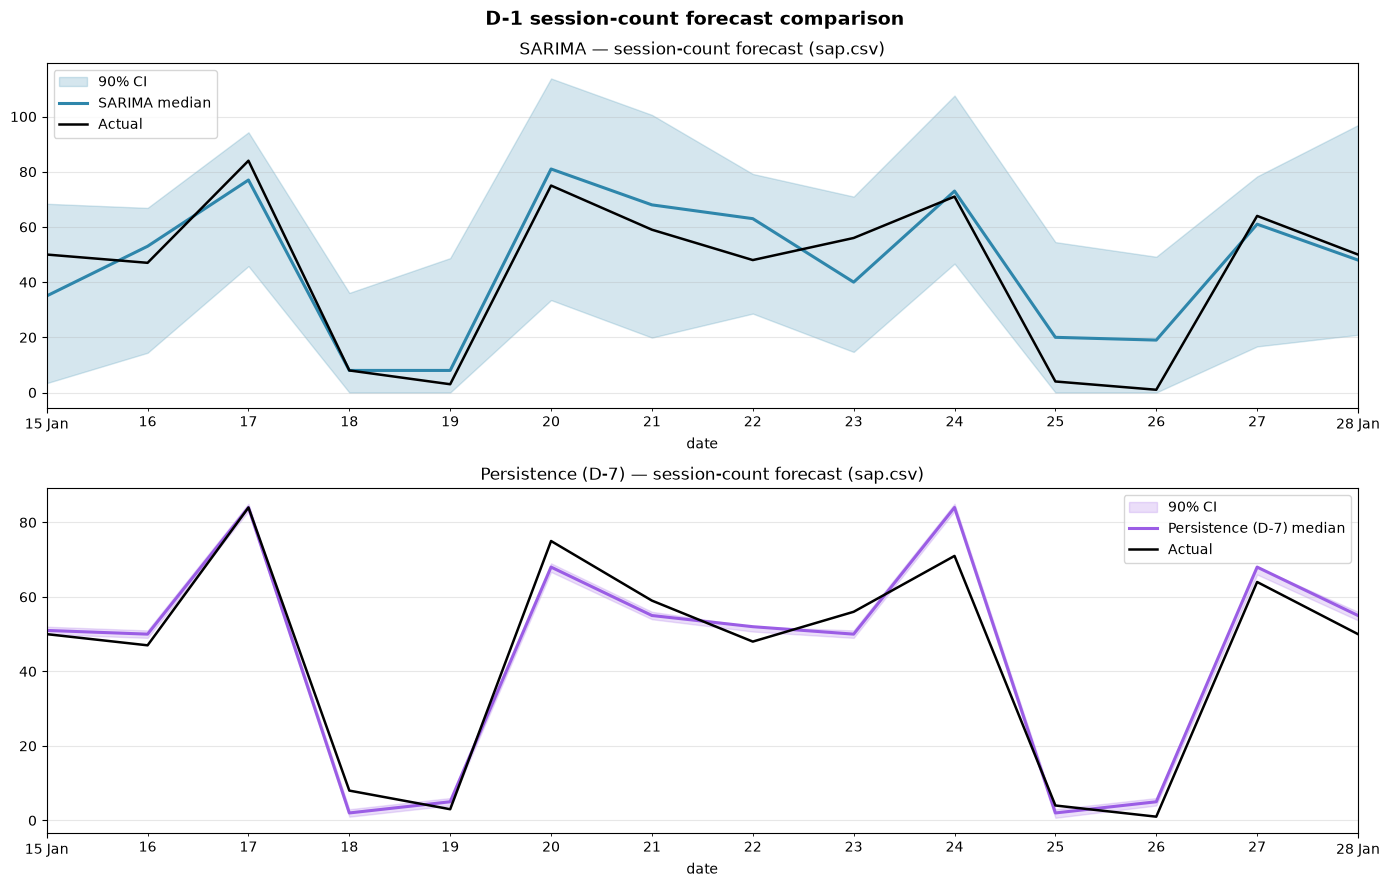

In [8]:
def pivot_forecast(pred_df):
    """Pivot (date x scenario) -> wide DataFrame with DatetimeIndex."""
    p = pred_df.pivot(index="date", columns="scenario", values="n_sessions")
    p.index = pd.to_datetime(p.index)
    return p

piv_sarima = pivot_forecast(pred_sarima)
piv_pers   = pivot_forecast(pred_pers)
actual_aligned = actual_counts.reindex(piv_sarima.index, fill_value=0)
actual_aligned.index = pd.to_datetime(actual_aligned.index)

fig, axes = plt.subplots(2, 1, figsize=(14, 9))
for ax, (piv, name, color) in zip(axes, [
    (piv_sarima, "SARIMA", "#2E86AB"),
    (piv_pers,   "Persistence (D-7)", "#9B5DE5"),
]):
    ax.fill_between(piv.index, piv.quantile(0.05, axis=1),
                    piv.quantile(0.95, axis=1), alpha=0.2, color=color,
                    label="90% CI")
    piv.median(axis=1).plot(ax=ax, color=color, linewidth=2.2, label=f"{name} median")
    actual_aligned.plot(ax=ax, color="black", linewidth=1.8, label="Actual", zorder=5)
    ax.set_title(f"{name} — session-count forecast ({os.path.basename(DATA_PATH)})")
    ax.legend(); ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))

fig.suptitle("D-1 session-count forecast comparison", fontsize=14, fontweight="bold")
fig.tight_layout()
plt.savefig("outputs/05_forecast_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

In [9]:
def eval_forecast(pred_df, actual_series, name):
    piv = pivot_forecast(pred_df)
    med = piv.median(axis=1).reindex(actual_series.index, fill_value=0)
    act = actual_series.reindex(med.index, fill_value=0)
    mae  = float(np.abs(med - act).mean())
    rmse = float(np.sqrt(((med - act) ** 2).mean()))
    nz   = act > 0
    mape = float(np.abs((med[nz] - act[nz]) / act[nz]).mean()) * 100 if nz.any() else 0.0
    return {"Model": name, "MAE": round(mae, 1), "RMSE": round(rmse, 1), "MAPE (%)": round(mape, 1)}

metrics_rows = [
    eval_forecast(pred_sarima, actual_aligned, "SARIMA"),
    eval_forecast(pred_pers,   actual_aligned, "Persistence (D-7)"),
]
if pred_nhits is not None:
    metrics_rows.insert(1, eval_forecast(pred_nhits, actual_aligned, "NHiTS"))

metrics_df = pd.DataFrame(metrics_rows)
print("── Forecast metrics ─────────────────────────────────────────────────────")
print(metrics_df.to_string(index=False))

── Forecast metrics ─────────────────────────────────────────────────────
            Model  MAE  RMSE  MAPE (%)
           SARIMA  8.6  10.5     179.5
Persistence (D-7)  4.4   5.3      47.8


## 7. GEARSModel — simulate individual sessions

GMM backend only (VAE is out of scope for this notebook). `stratify_by` stays at the
package default `["day_of_week", "season"]` — no `department`/`location_type` context is
available for this dataset, and none is required.

In [10]:
model = GEARSModel(
    n_components="auto",
    stratify_by=["day_of_week", "season"],
    forecaster_method="sarima",
    forecaster_use_holidays=FORECASTER_USE_HOLIDAYS,
    forecaster_country=FORECASTER_COUNTRY,
    max_samples_per_context=MAX_SAMPLES,
    n_scenarios=N_SCENARIOS,
)
model.fit(train_df, verbose=True)
print(repr(model.gmm_))
print(f"\nForecaster mean_daily_ : {model.forecaster_.mean_daily_:.1f} sess/day")
print(f"Real eval sessions/day : {actual_counts.mean():.1f} sess/day")

simulated_sessions = model.simulate_short_term(
    start_date=EVAL_DATE, horizon=HORIZON, n_scenarios=N_SCENARIOS, seed=42,
)
sc0 = simulated_sessions[simulated_sessions["scenario"] == 0]
print(f"\nSimulated: {len(simulated_sessions):,} rows total | {N_SCENARIOS} scenarios")
print(f"Scenario-0 sessions/day : {sc0.groupby('date').size().mean():.1f}")
print(f"Scenario-0 energy/day   : {sc0.groupby('date')['energy'].sum().mean():.0f} kWh")
print(f"Real       energy/day   : "
      f"{eval_df.groupby(eval_df['arrival_time'].dt.date)['energy'].sum().mean():.0f} kWh")

[GEARS] Loaded 12,817 sessions.
            count       mean        std       min        25%        50%        75%        max  missing_%
duration  12817.0   4.204399   3.089446  0.002778   2.083611   3.596111   5.266389  23.743611        0.0
energy    12817.0  24.077274  14.406329  0.001000  13.526000  21.542000  32.144000  93.097000        0.0
[GEARS] Fitting GMM on 12,817 sessions …


[GEARS] Fitting session-count forecaster (sarima) …


[GEARS] Fitting complete ✓
EVSessionModel(n_contexts=28, stratify_by=['day_of_week', 'season'], n_components='auto', max_samples=500, fitted=True)
EVSessionModel(n_contexts=28, stratify_by=['day_of_week', 'season'], n_components='auto', max_samples=500, fitted=True)

Forecaster mean_daily_ : 35.1 sess/day
Real eval sessions/day : 44.3 sess/day



Simulated: 10,202 rows total | 15 scenarios
Scenario-0 sessions/day : 48.9
Scenario-0 energy/day   : 1021 kWh
Real       energy/day   : 1184 kWh


## 8. Daily energy forecast

**Design:** GEARS predicts daily energy as `n_sessions(t) x energy_per_session(t)` where
`n_sessions(t)` comes from the SARIMA forecaster (Section 6) and `energy_per_session(t)`
is drawn from the GMM conditioned on day-of-week and season. Both fitted on `train_df`,
evaluated on `eval_df`.

Real   energy/day: 1184 kWh
GEARS  median/day: 1031 kWh
Ratio GEARS/real: 0.87x  (target: 0.7-1.3x)
Energy scales are consistent.


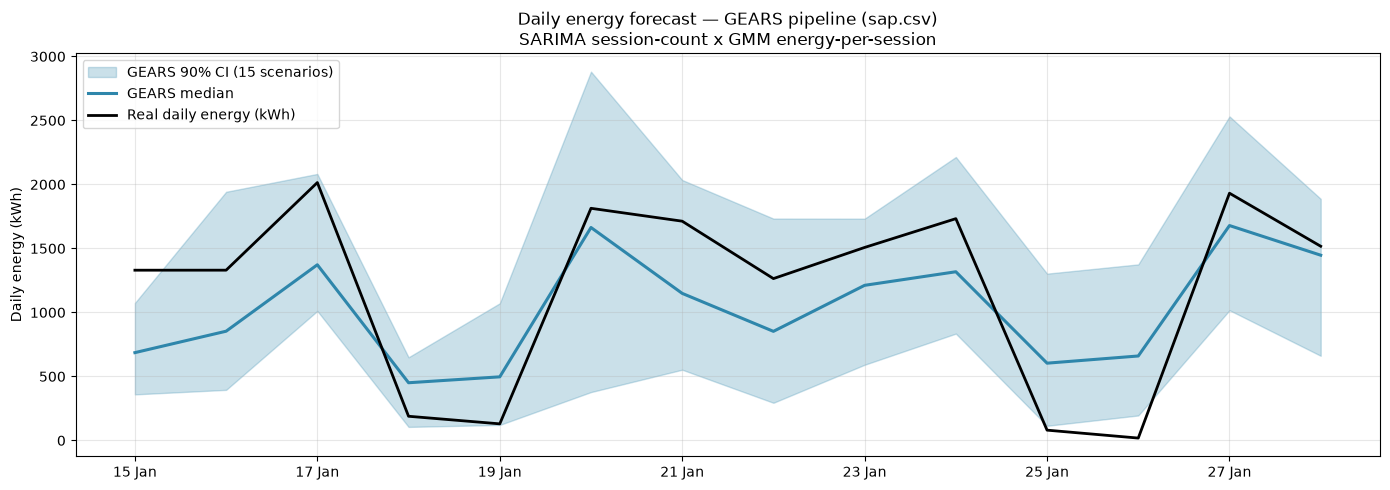

In [11]:
eval_dates = pd.date_range(EVAL_DATE, periods=HORIZON, freq="D")

real_daily_energy = (
    eval_df.groupby(eval_df["arrival_time"].dt.date)["energy"]
    .sum()
    .rename("energy_kwh")
)
real_daily_energy.index = pd.to_datetime(real_daily_energy.index)
real_daily_energy = real_daily_energy.reindex(eval_dates, fill_value=0)

sims = simulated_sessions.copy()
sims["date"] = pd.to_datetime(sims["date"])
pred_pivot = (
    sims.groupby(["date", "scenario"])["energy"]
    .sum()
    .reset_index()
    .pivot_table(index="date", columns="scenario", values="energy")
)
pred_pivot.index = pd.to_datetime(pred_pivot.index)
pred_pivot = pred_pivot.reindex(eval_dates, fill_value=np.nan)

pred_med_e = pred_pivot.median(axis=1).mean()
real_mean_e = real_daily_energy.mean()
ratio = pred_med_e / max(real_mean_e, 1)
print(f"Real   energy/day: {real_mean_e:.0f} kWh")
print(f"GEARS  median/day: {pred_med_e:.0f} kWh")
print(f"Ratio GEARS/real: {ratio:.2f}x  (target: 0.7-1.3x)")
if ratio < 0.5 or ratio > 3:
    print("Ratio out of expected range — check training window / dataset density.")
else:
    print("Energy scales are consistent.")

fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(
    pred_pivot.index,
    pred_pivot.quantile(0.05, axis=1),
    pred_pivot.quantile(0.95, axis=1),
    alpha=0.25, color="#2E86AB",
    label=f"GEARS 90% CI ({N_SCENARIOS} scenarios)",
)
ax.plot(pred_pivot.index, pred_pivot.median(axis=1).values,
        color="#2E86AB", linewidth=2.2, label="GEARS median")
ax.plot(real_daily_energy.index, real_daily_energy.values,
        color="black", linewidth=2, label="Real daily energy (kWh)")
ax.set_ylabel("Daily energy (kWh)")
ax.set_title(f"Daily energy forecast — GEARS pipeline ({os.path.basename(DATA_PATH)})\n"
             "SARIMA session-count x GMM energy-per-session")
ax.legend(); ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
fig.tight_layout()
plt.savefig("outputs/05_energy_forecast.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Real vs. simulated distributions

── Distribution distances ─────────────────────────────────────────────
 feature  wasserstein  kl_divergence  ks_statistic  ks_pvalue
    hour       0.5580         0.1874        0.0976     0.0037
duration       0.6985         0.1168        0.0814     0.0251
  energy       6.2182         0.5012        0.2026     0.0000


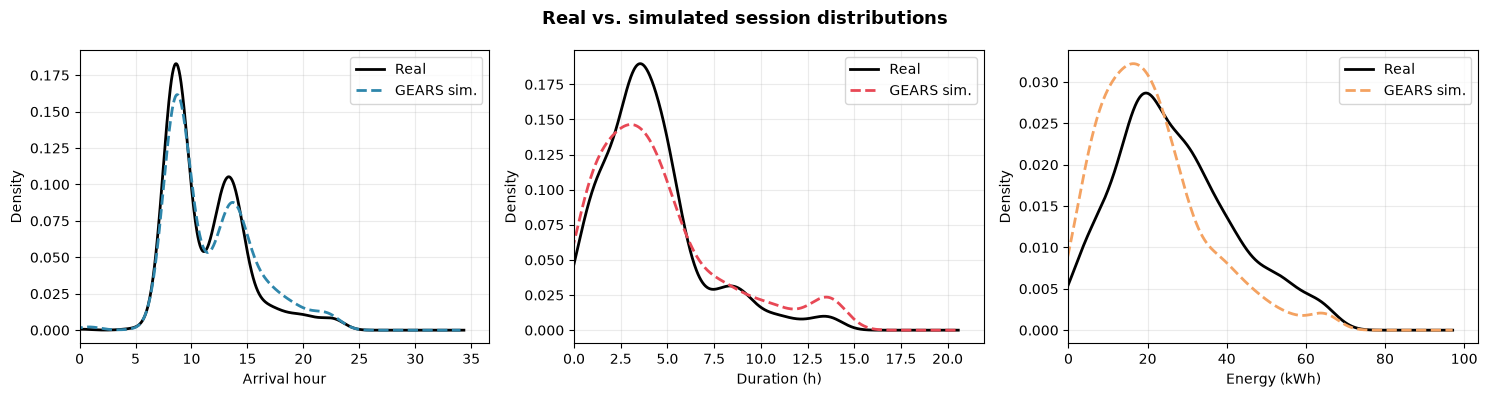

In [12]:
sim_sc0 = simulated_sessions[simulated_sessions["scenario"] == 0].copy()

dist_metrics = distribution_comparison(eval_df, sim_sc0)
print("── Distribution distances ─────────────────────────────────────────────")
print(dist_metrics.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (sim_col, real_col, label, color) in zip(axes, [
    ("arrival_hour", "hour",     "Arrival hour", "#2E86AB"),
    ("duration",     "duration", "Duration (h)", "#E84855"),
    ("energy",       "energy",   "Energy (kWh)", "#F4A261"),
]):
    q99 = eval_df[real_col].quantile(0.99)
    eval_df[real_col].clip(0, q99).plot.kde(ax=ax, label="Real", color="black", linewidth=2)
    sim_sc0[sim_col].clip(0, q99).plot.kde(ax=ax, label="GEARS sim.", color=color, linewidth=2, linestyle="--")
    ax.set_xlabel(label); ax.set_xlim(left=0)
    ax.legend(); ax.grid(True, alpha=0.25)

fig.suptitle("Real vs. simulated session distributions", fontsize=13, fontweight="bold")
fig.tight_layout()
plt.savefig("outputs/05_distribution_kde.png", dpi=150, bbox_inches="tight")
plt.show()

## 10. V1G smart charging — optimisation

In [13]:
n_slots = HORIZON * 24 * (60 // RESOLUTION)
price_signal = make_price_signal(
    start=EVAL_DATE, periods=n_slots,
    resolution_min=RESOLUTION, pattern="day_night", seed=42,
)
print(f"Price signal: {price_signal.min():.3f} - {price_signal.max():.3f} EUR/kWh | {len(price_signal)} slots")

rng = np.random.default_rng(99)

oracle_sessions = eval_df.copy()
oracle_sessions["power_kw"] = rng.choice([7.4, 22.0], size=len(oracle_sessions), p=[0.6, 0.4])

pred_sessions = sim_sc0.copy()
pred_sessions["arrival_time"] = (
    pd.to_datetime(pred_sessions["date"].astype(str))
    + pd.to_timedelta(pred_sessions["arrival_hour"].astype(float), unit="h")
)
pred_sessions["power_kw"] = rng.choice([7.4, 22.0], size=len(pred_sessions), p=[0.6, 0.4])

pers_start = pd.Timestamp(EVAL_DATE) - pd.Timedelta(weeks=1)
pers_sessions = df_recent[
    (df_recent["arrival_time"] >= pers_start) &
    (df_recent["arrival_time"] <  pers_start + pd.Timedelta(days=HORIZON))
].copy()
pers_sessions["arrival_time"] = pd.to_datetime(pers_sessions["arrival_time"]) + pd.Timedelta(weeks=1)
pers_sessions["date"]         = pers_sessions["arrival_time"].dt.date
pers_sessions["power_kw"]     = rng.choice([7.4, 22.0], size=len(pers_sessions), p=[0.6, 0.4])

opt = SmartChargingOptimizer(signal_type="price", resolution_min=RESOLUTION)
oracle_opt = opt.optimise(oracle_sessions, price_signal)
pred_opt   = opt.optimise(pred_sessions,   price_signal)
pers_opt   = opt.optimise(pers_sessions,   price_signal)
print(f"Oracle optimised: {oracle_opt['cost_plug'].notna().sum()} sessions")
print(f"GEARS  optimised: {pred_opt['cost_plug'].notna().sum()} sessions")

Price signal: 0.074 - 0.321 EUR/kWh | 672 slots


Oracle optimised: 604 sessions
GEARS  optimised: 663 sessions


## 11. Regret analysis

Each strategy is evaluated on its own session pool, cost normalised by energy. Hard
guarantee: `oracle_smart <= oracle_plug` on the same sessions (V1G savings >= 0).
Cross-pool comparisons (oracle vs. persistence/GEARS) are illustrative only.

── Regret analysis (EUR/kWh, each strategy on its own sessions) ──────────
  Oracle  + V1G (real sessions):  0.2067 EUR/kWh
  Oracle  + Plug:                 0.2320 EUR/kWh  -> V1G saves 0.0253 EUR/kWh
  GEARS   + V1G (pred sessions):  0.2204 EUR/kWh
  GEARS   + Plug:                 0.2587 EUR/kWh  -> V1G saves 0.0383 EUR/kWh
  Persistence + V1G (D-7 sess.):  0.2076 EUR/kWh  (illustrative)
  Regret GEARS vs oracle:         0.0137 EUR/kWh  (>= 0 by construction)

  Oracle guarantee: V1G <= Plug on same sessions: True
  GEARS  guarantee: V1G <= Plug on same sessions: True


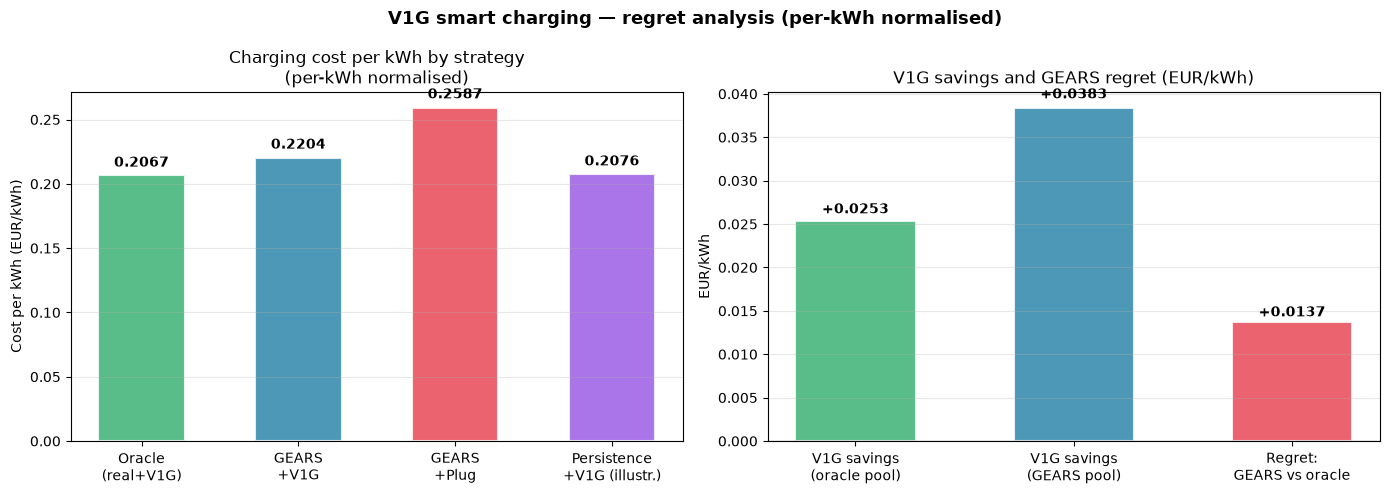

In [14]:
energy_oracle = max(oracle_sessions["energy"].sum(), 1e-9)
energy_pred   = max(pred_sessions["energy"].sum(),   1e-9)
energy_pers   = max(pers_sessions["energy"].sum(),   1e-9)

cpkwh_oracle_smart = oracle_opt["cost_smart"].sum() / energy_oracle
cpkwh_oracle_plug  = oracle_opt["cost_plug"].sum()  / energy_oracle
cpkwh_pred_smart   = pred_opt["cost_smart"].sum()   / energy_pred
cpkwh_pred_plug    = pred_opt["cost_plug"].sum()    / energy_pred
cpkwh_pers_smart   = pers_opt["cost_smart"].sum()   / energy_pers

v1g_savings_oracle = cpkwh_oracle_plug - cpkwh_oracle_smart
v1g_savings_gears  = cpkwh_pred_plug   - cpkwh_pred_smart
regret_gears_vs_oracle = max(0.0, cpkwh_pred_smart - cpkwh_oracle_smart)

print("── Regret analysis (EUR/kWh, each strategy on its own sessions) ──────────")
print(f"  Oracle  + V1G (real sessions):  {cpkwh_oracle_smart:.4f} EUR/kWh")
print(f"  Oracle  + Plug:                 {cpkwh_oracle_plug:.4f} EUR/kWh  -> V1G saves {v1g_savings_oracle:.4f} EUR/kWh")
print(f"  GEARS   + V1G (pred sessions):  {cpkwh_pred_smart:.4f} EUR/kWh")
print(f"  GEARS   + Plug:                 {cpkwh_pred_plug:.4f} EUR/kWh  -> V1G saves {v1g_savings_gears:.4f} EUR/kWh")
print(f"  Persistence + V1G (D-7 sess.):  {cpkwh_pers_smart:.4f} EUR/kWh  (illustrative)")
print(f"  Regret GEARS vs oracle:         {regret_gears_vs_oracle:.4f} EUR/kWh  (>= 0 by construction)")
print()
print(f"  Oracle guarantee: V1G <= Plug on same sessions: {cpkwh_oracle_smart <= cpkwh_oracle_plug}")
print(f"  GEARS  guarantee: V1G <= Plug on same sessions: {cpkwh_pred_smart <= cpkwh_pred_plug}")

COLORS = {"oracle": "#3BB273", "gears_smart": "#2E86AB",
          "gears_plug": "#E84855", "pers": "#9B5DE5"}
labels_bar = ["Oracle\n(real+V1G)", "GEARS\n+V1G", "GEARS\n+Plug", "Persistence\n+V1G (illustr.)"]
costs_pk = [cpkwh_oracle_smart, cpkwh_pred_smart, cpkwh_pred_plug, cpkwh_pers_smart]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax = axes[0]
bars = ax.bar(labels_bar, costs_pk, color=list(COLORS.values()),
              alpha=0.85, edgecolor="white", linewidth=1.5, width=0.55)
for bar, v in zip(bars, costs_pk):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.02,
            f"{v:.4f}", ha="center", va="bottom", fontsize=10, fontweight="bold")
ax.set_ylabel("Cost per kWh (EUR/kWh)")
ax.set_title("Charging cost per kWh by strategy\n(per-kWh normalised)")
ax.grid(axis="y", alpha=0.3)

ax2 = axes[1]
items = {
    "V1G savings\n(oracle pool)": v1g_savings_oracle,
    "V1G savings\n(GEARS pool)":  v1g_savings_gears,
    "Regret:\nGEARS vs oracle":   regret_gears_vs_oracle,
}
rcolors = ["#3BB273", "#2E86AB", "#E84855"]
rbars = ax2.bar(list(items.keys()), list(items.values()),
                color=rcolors, alpha=0.85, edgecolor="white", linewidth=1.5, width=0.55)
for bar, v in zip(rbars, items.values()):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.02,
             f"{v:+.4f}", ha="center", va="bottom", fontsize=10, fontweight="bold")
ax2.axhline(0, color="black", linewidth=0.8)
ax2.set_ylabel("EUR/kWh")
ax2.set_title("V1G savings and GEARS regret (EUR/kWh)")
ax2.grid(axis="y", alpha=0.3)

fig.suptitle("V1G smart charging — regret analysis (per-kWh normalised)",
             fontsize=13, fontweight="bold")
fig.tight_layout()
plt.savefig("outputs/05_regret_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

## 12. Load-shift visualisation

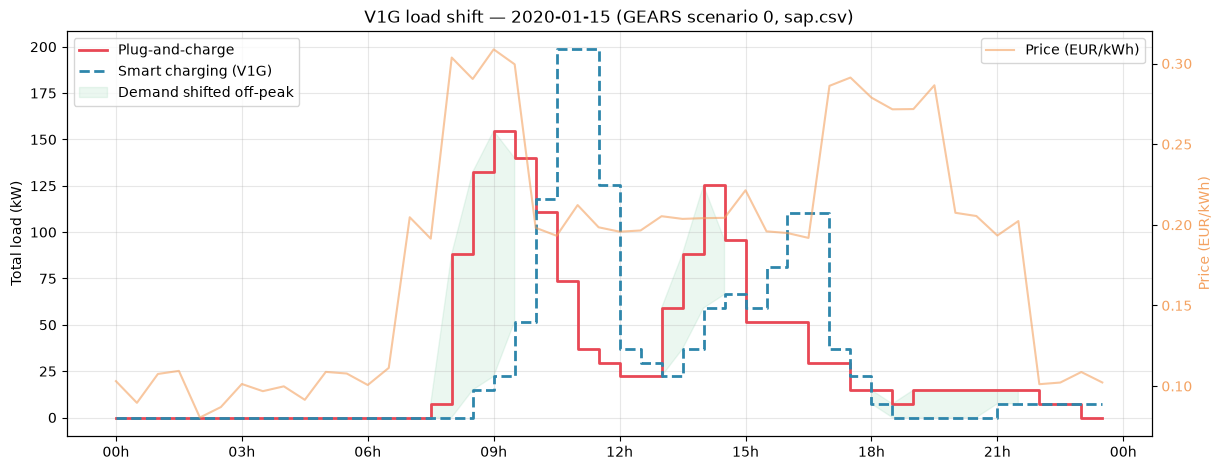

In [15]:
first_day   = pd.Timestamp(EVAL_DATE)
n_slots_day = 24 * 60 // RESOLUTION
res_h       = RESOLUTION / 60.0

def build_load_curve(sessions_df: pd.DataFrame, ref_date: pd.Timestamp,
                     scheduled: bool = False) -> np.ndarray:
    """Aggregate sessions into a (n_slots_day,) kW vector for a single day."""
    load = np.zeros(n_slots_day)
    day_date = ref_date.date()
    day_rows = sessions_df[
        pd.to_datetime(
            sessions_df.get("date",
                sessions_df.get("arrival_time", pd.Series(dtype="datetime64[ns]")))
        ).dt.date == day_date
    ].copy()
    for _, row in day_rows.iterrows():
        power      = float(row.get("power_kw", 7.4))
        energy_kw  = float(row.get("energy", 10)) / 0.9
        n_slots    = max(1, int(np.ceil(energy_kw / (power * res_h))))
        arr_col    = "scheduled_start" if (scheduled and pd.notna(row.get("scheduled_start"))) \
                     else "arrival_time"
        if pd.isna(row.get(arr_col)):
            continue
        arr        = pd.Timestamp(row[arr_col])
        s0         = int((arr - ref_date).total_seconds() / 60 / RESOLUTION)
        s1         = min(s0 + n_slots, n_slots_day)
        if 0 <= s0 < n_slots_day:
            load[s0:s1] += power
    return load

times      = pd.date_range(first_day, periods=n_slots_day, freq=f"{RESOLUTION}min")
plug_load  = build_load_curve(pred_opt, first_day, scheduled=False)
smart_load = build_load_curve(pred_opt, first_day, scheduled=True)
day_signal = price_signal[
    (price_signal.index >= first_day) &
    (price_signal.index <  first_day + pd.Timedelta(days=1))
]

fig, ax1 = plt.subplots(figsize=(14, 5))
ax1.step(times, plug_load,  label="Plug-and-charge",     color="#E84855",
         linewidth=2.0, where="post")
ax1.step(times, smart_load, label="Smart charging (V1G)", color="#2E86AB",
         linewidth=2.0, where="post", linestyle="--")
ax1.fill_between(times, plug_load, smart_load, where=smart_load < plug_load,
                 alpha=0.1, color="#3BB273", label="Demand shifted off-peak")
ax1.set_ylabel("Total load (kW)"); ax1.legend(loc="upper left"); ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
if not day_signal.empty:
    ax2.plot(day_signal.index, day_signal.values,
             color="#F4A261", alpha=0.6, linewidth=1.5, label="Price (EUR/kWh)")
    ax2.set_ylabel("Price (EUR/kWh)", color="#F4A261")
    ax2.tick_params(axis="y", labelcolor="#F4A261")
    ax2.legend(loc="upper right")

ax1.set_title(f"V1G load shift — {first_day.date()} (GEARS scenario 0, {os.path.basename(DATA_PATH)})")
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Hh"))
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Hh"))
plt.subplots_adjust(top=0.92)
plt.savefig("outputs/05_load_curve.png", dpi=150, bbox_inches="tight")
plt.show()

## Summary

- `load_sessions()` handled this dataset with **zero dataset-specific code** in this
  notebook — all the aliasing/unit-conversion work lives in `gears/data/schemas.py`
  (Session 1 of this genericization effort).
- `GEARSModel` required no `department`/`location_type` context to fit or simulate;
  `stratify_by` fell back to its package default (`day_of_week`, `season`).
- The new `forecaster_use_holidays`/`forecaster_country` pass-through on `GEARSModel`
  (added in this session) avoids silently applying French bank holidays to a non-French
  SARIMA fit — set `FORECASTER_COUNTRY` above if you know your site's country.
- `SmartChargingOptimizer` and `distribution_comparison`/`forecast_metrics` are fully
  dataset-agnostic — they operate on canonical columns only, so nothing changed there.
- The `"french"` registry default and INSEE department-forecasting path (`gears/data/insee.py`)
  are untouched — this notebook simply doesn't use them, since this dataset has no
  department column.